## Franka Slide 

Check the RGB and Depth images of franka slide dataset. 

In [ ]:
import h5py
import torch
from omegaconf import OmegaConf

checkpoint_dir = "ckpt/dbc/pegmcircle_dbc_test_tactile/"
loaded_args = OmegaConf.load(checkpoint_dir + "/config.yaml")
loaded_args.model_path = checkpoint_dir + "/model.pt"



(224, 224)
0 1484


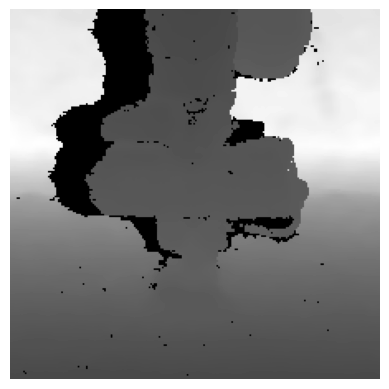

In [28]:
import numpy as np

sample = frankaslide_dataset["demo_2"]["obs"]["agentview"]["depth"][100]
print(sample.shape)
print(np.min(sample), np.max(sample))

import matplotlib.pyplot as plt

plt.imshow(sample.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [20]:
frankaslide_dataset["demo_48"]["obs"].keys()

<KeysViewHDF5 ['agentview', 'delta_time', 'ee_euler', 'ee_pos', 'gripper_state', 'gripper_width', 'joint_pos', 'joint_vel', 'tactile']>

(224, 224, 3)
0 255


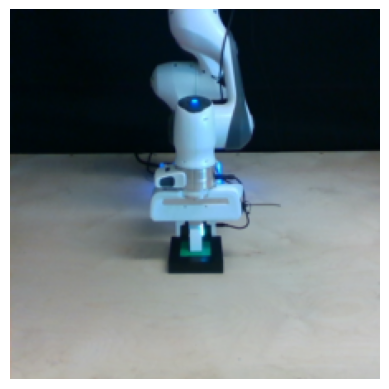

In [37]:
sample = frankaslide_dataset["demo_9"]["obs"]["agentview"]["color"][125]
print(sample.shape)
# sample = sample[..., ::-1] # BGR to RGB
print(np.min(sample), np.max(sample))

plt.imshow(sample)
plt.axis('off')
plt.show()

In [38]:
# Collect all actions from the dataset and compute their norms
actions = []
for demo in frankaslide_dataset.keys():
    demo_actions = frankaslide_dataset[demo]["actions"][:][:, :3]
    actions.append(demo_actions)
actions = np.concatenate(actions, axis=0)

# Compute the norm of each action vector
actions_norm = np.linalg.norm(actions, axis=1)
print("Average norm:", actions_norm.mean(), "\nMax norm:", actions_norm.max(), "\nMin norm:", actions_norm.min(), "\nMedian norm:", np.median(actions_norm))

Average norm: 0.0015929228304988508 
Max norm: 0.021530264650448855 
Min norm: 0.0 
Median norm: 0.0


In [39]:
demo_lengths = []
for demo_i in frankaslide_dataset.keys():
    length = frankaslide_dataset[demo_i]["actions"].shape[0]
    demo_lengths.append(length)
avg_demo_length = np.mean(demo_lengths)
max_demo_length = np.max(demo_lengths)
min_demo_length = np.min(demo_lengths)
print("Average demo length:", avg_demo_length)
print("Max demo length:", max_demo_length)
print("Min demo length:", min_demo_length)

Average demo length: 168.68852459016392
Max demo length: 296
Min demo length: 97


## Robomimic image

Plot the robomimic Can image for comparison. 

(84, 84, 3)
2 251


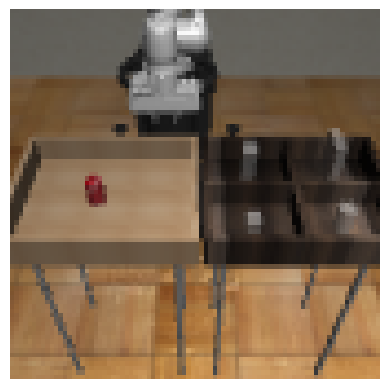

In [26]:
robomimic_dataset = h5py.File('libs/CleanDiffuser/datasets/can/ph/image.hdf5', 'r')
sample = robomimic_dataset["data"]["demo_10"]["obs"]["agentview_image"][0]
print(sample.shape)
print(np.min(sample), np.max(sample))

import matplotlib.pyplot as plt

plt.imshow(sample)
plt.axis('off')
plt.show()